In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

plt.style.use('ggplot')

--- Результаты проверки гипотез ---
Область принятия H0: [0.767, 1.272]
Статистика для длины (x): 0.868 -> Не отвергаем H0
Статистика для ширины (y): 0.838 -> Не отвергаем H0


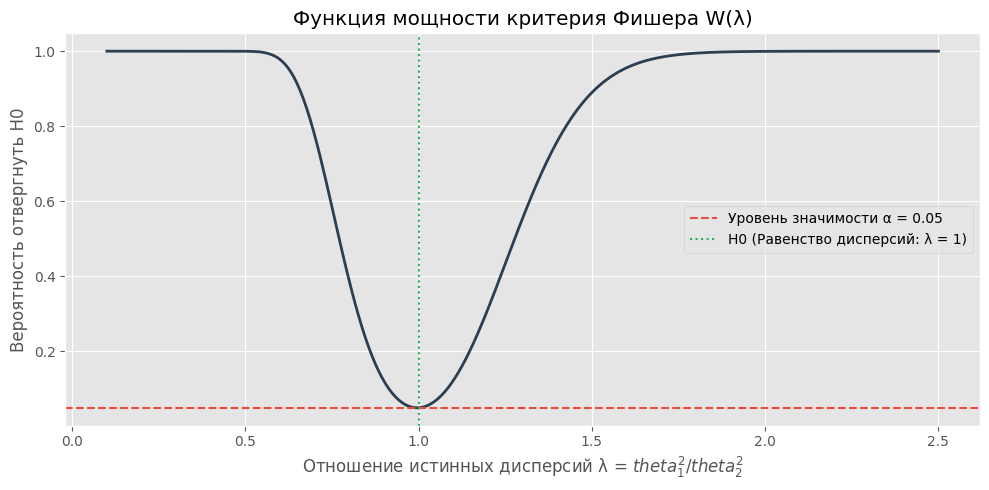

In [4]:
alpha = 0.05
n = 139
m = 1000

sigma2_1x = 5.722**2
sigma2_1y = 4.612**2
sigma2_2x = 6.161**2
sigma2_2y = 5.055**2

S2_1x = (n / (n - 1)) * sigma2_1x
S2_1y = (n / (n - 1)) * sigma2_1y
S2_2x = (m / (m - 1)) * sigma2_2x
S2_2y = (m / (m - 1)) * sigma2_2y

delta_x = S2_1x / S2_2x
delta_y = S2_1y / S2_2y

df1, df2 = n - 1, m - 1
f_left = st.f.ppf(alpha / 2, df1, df2)
f_right = st.f.ppf(1 - alpha / 2, df1, df2)

print("--- Результаты проверки гипотез ---")
print(f"Область принятия H0: [{f_left:.3f}, {f_right:.3f}]")
print(f"Статистика для длины (x): {delta_x:.3f} -> " + ("Отвергаем H0" if not (f_left < delta_x < f_right) else "Не отвергаем H0"))
print(f"Статистика для ширины (y): {delta_y:.3f} -> " + ("Отвергаем H0" if not (f_left < delta_y < f_right) else "Не отвергаем H0"))

lambda_vals = np.linspace(0.1, 2.5, 500)

W = 1 - st.f.cdf(f_right, df1, df2, scale=lambda_vals) + st.f.cdf(f_left, df1, df2, scale=lambda_vals)

plt.figure(figsize=(10, 5))
plt.plot(lambda_vals, W, color='#2c3e50', lw=2)
plt.axhline(alpha, color='#e74c3c', linestyle='--', label=f'Уровень значимости α = {alpha}')
plt.axvline(1.0, color='#27ae60', linestyle=':', label='H0 (Равенство дисперсий: λ = 1)')

plt.title('Функция мощности критерия Фишера W(λ)')
plt.xlabel('Отношение истинных дисперсий λ = $theta_1^2 /theta_2^2$')
plt.ylabel('Вероятность отвергнуть H0')
plt.legend()
plt.tight_layout()
plt.show()